In [7]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from google.colab import drive
from tqdm import tqdm
import matplotlib.pyplot as plt
from itertools import product

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, f1_score

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install openimages

In [5]:
DATA_DIR = "/content/drive/MyDrive/masters/gmm/lab1/data"

print(os.listdir(DATA_DIR))

# Select 3 classes (must exist in ImageNet)
SELECTED_CLASSES = ["Bee", "Pizza", "Koala"]

SELECTED_CLASSES_LOWER = [ cls.lower() for cls in SELECTED_CLASSES  ]

print(SELECTED_CLASSES_LOWER)

NUM_CLASSES = len(SELECTED_CLASSES)

['bee', 'pizza', 'teddy bear', 'bee.png', 'rabbit', 'turtle', 'koala', '.ipynb_checkpoints', 'all.png']
['bee', 'pizza', 'koala']


In [8]:
from openimages.download import download_dataset

#download_dataset(DATA_DIR, SELECTED_CLASSES_LOWER, limit=1000)
download_dataset(DATA_DIR, ['Koala'], limit=300)

ModuleNotFoundError: No module named 'openimages'

In [10]:
weights = ResNet50_Weights.IMAGENET1K_V1
imagenet_labels = weights.meta["categories"]

class_to_imagenet_idx = {
    cls: imagenet_labels.index(cls) for cls in SELECTED_CLASSES_LOWER
}

imagenet_indices = list(class_to_imagenet_idx.values())
print(class_to_imagenet_idx)

{'bee': 309, 'pizza': 963, 'koala': 105}


In [11]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

In [44]:
DATA_DIR = 'drive/MyDrive/masters/gmm/lab1/data'
os.listdir(DATA_DIR)

['bee',
 'pizza',
 'teddy bear',
 'bee.png',
 'rabbit',
 'turtle',
 'koala',
 '.ipynb_checkpoints',
 'all.png',
 'all_probs.npy',
 'all_labels.npy',
 'karve.png']

In [13]:
class MyAmazingDataset(Dataset):
  def __init__(self, root_dir, class_names, transform=None):
    self.root_dir = root_dir
    self.class_names = class_names
    self.transform = transform

    self.samples = []

    for class_idx, class_name in enumerate(class_names):
      class_path = os.path.join(root_dir, class_name)

      for root, _, files in os.walk(class_path):
        for file in files:
          if file.lower().endswith((".jpg", ".png", ".jpeg")):
            self.samples.append((os.path.join(root, file), class_idx))

  def __len__(self):
    return len(self.samples)

  def __getitem__(self, idx):
    img_path, label = self.samples[idx]

    image = Image.open(img_path).convert("RGB")

    if self.transform:
      image = self.transform(image)

    label_vec = torch.zeros(NUM_CLASSES)
    label_vec[label] = 1

    return image, label_vec

In [14]:
dataset = MyAmazingDataset(
  DATA_DIR,
  SELECTED_CLASSES_LOWER,
  transform=transform
)

loader = DataLoader(
  dataset,
  batch_size=32,
  shuffle=True,
  num_workers=2,
  prefetch_factor=2
)

print("Total samples:", len(dataset))

Total samples: 1542


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = resnet50(weights=weights)
model = model.to(device)
model.eval()

print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 114MB/s]


Device: cpu


In [19]:
all_probs = []
all_labels = []

batch_limit = 32 # 32 batches x 32 samples per batch > 1000 samples

with torch.no_grad():
  for (images, labels), batch_id in tqdm(zip(loader, [ i for i in range(batch_limit) ])):

    if batch_limit <= batch_id:
      break

    images = images.to(device)

    outputs = model(images)  # (B, 1000)

    outputs_3 = outputs[:, imagenet_indices]  # (B, 3)
    probs_3 = torch.sigmoid(outputs_3)        # multi-label probabilities

    all_probs.append(probs_3.cpu())
    all_labels.append(labels)

all_probs = torch.cat(all_probs).numpy()
all_labels = torch.cat(all_labels).numpy()

32it [04:55,  9.24s/it]


In [20]:
DATA_DIR

'drive/MyDrive/masters/gmm/lab1/data'

In [21]:
np.save(DATA_DIR + "/all_probs.npy", all_probs)
np.save(DATA_DIR + "/all_labels.npy", all_labels)

In [22]:
all_probs = np.load(DATA_DIR + "/all_probs.npy")
all_labels = np.load(DATA_DIR + "/all_labels.npy")

In [23]:
preds = (all_probs >= 0.5).astype(int)

acc  = accuracy_score(all_labels, preds)
prec = precision_score(all_labels, preds, average="samples", zero_division=0)
f1   = f1_score(all_labels, preds, average="samples", zero_division=0)

print("Statistics without threshold analysis")
print(f"\nAccuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"F1 Score : {f1:.3f}")

Statistics without threshold analysis

Accuracy : 0.607
Precision: 0.794
F1 Score : 0.859


In [24]:
thresholds = np.linspace(0.05, 0.95, 19)
best_thresholds = np.zeros(NUM_CLASSES)

for c in range(NUM_CLASSES):
    f1s = []

    for t in thresholds:
        preds = (all_probs[:, c] >= t).astype(int)
        f1s.append(f1_score(all_labels[:, c], preds, zero_division=0))

    best_thresholds[c] = thresholds[np.argmax(f1s)]

In [25]:
print("Label positives:", all_labels.sum(axis=0))
print("Max probs:", all_probs.max(axis=0))
print("Mean probs:", all_probs.mean(axis=0))

Label positives: [670. 305.  49.]
Max probs: [1. 1. 1.]
Mean probs: [0.7958532 0.5573678 0.2764194]


In [26]:
preds = (all_probs >= best_thresholds).astype(int)

acc  = accuracy_score(all_labels, preds)
prec = precision_score(all_labels, preds, average="samples", zero_division=0)
f1   = f1_score(all_labels, preds, average="samples", zero_division=0)

print("Best per-class thresholds:")
for cls, t in zip(SELECTED_CLASSES, best_thresholds):
    print(f"{cls}: {t:.2f}")

print(f"\nAccuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"F1 Score : {f1:.3f}")

Best per-class thresholds:
Bee: 0.95
Pizza: 0.95
Koala: 0.95

Accuracy : 0.934
Precision: 0.963
F1 Score : 0.972


In [27]:
def predict_classes(img) -> list[str]:
  image = img.convert("RGB")
  image = transform(image).unsqueeze(0).to(device)

  with torch.no_grad():
    outputs = model(image)
    probs = torch.sigmoid(outputs[:, imagenet_indices])

    best_thresholds_t = torch.tensor(
      best_thresholds, device=probs.device
    )

    pred = probs >= best_thresholds_t
    
    classes = []
    for i, cls in enumerate(SELECTED_CLASSES):
      if pred[0][i]:
        classes.append(cls)
        
    return classes

['Bee']


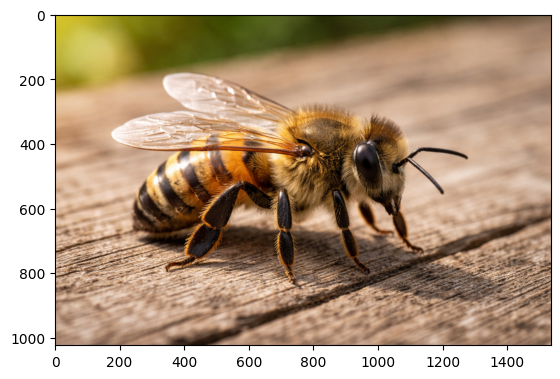

In [29]:
image_path = os.path.join(DATA_DIR, "bee.png")
image = Image.open(image_path)

ans = predict_classes(image)
print(ans)

plt.imshow(image)
plt.show()

['Pizza', 'Koala']


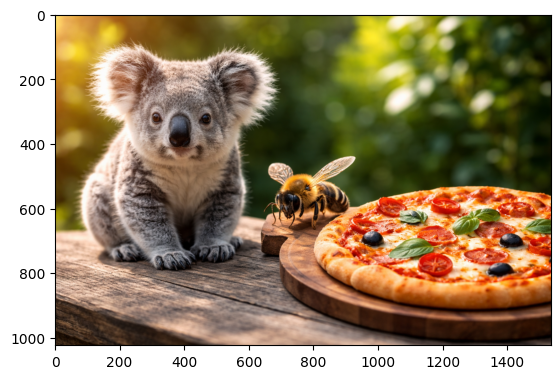

In [30]:
image_path = os.path.join(DATA_DIR, "all.png")
image = Image.open(image_path)

ans = predict_classes(image)
print(ans)

plt.imshow(image)
plt.show()

In [ ]:
image_path = os.path.join(DATA_DIR, "karve.png")
image = Image.open(image_path)

ans = predict_classes(image)
print(ans)

plt.imshow(image)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/karve.png'